In [1]:

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'
label_path = 'model/keypoint_classifier/keypoint_classifier_label.csv'

# Set number of classes

In [3]:
import csv

with open(label_path, newline='', encoding='utf-8-sig') as f:
    labels = [row[0] for row in csv.reader(f) if row and row[0] != '']

NUM_CLASSES = len(labels)
print(f'Detected {NUM_CLASSES} classes from {label_path}: {labels}')

Detected 28 classes from model/keypoint_classifier/keypoint_classifier_label.csv: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'DA', 'NU']


# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED, stratify=y_dataset)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 64)                2752      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 28)                924       
                                                                 
Total params: 5756 (22.48 KB)
Trainable params: 5756 (22.48 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


473/477 [============================>.] - ETA: 0s - loss: 2.0543 - accuracy: 0.3608
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
477/477 [==============================] - 3s 3ms/step - loss: 2.0500 - accuracy: 0.3617 - val_loss: 1.0463 - val_accuracy: 0.7132
Epoch 2/1000
 54/477 [==>...........................] - ETA: 0s - loss: 1.4325 - accuracy: 0.5153

e:\licenta\DeafEar\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


457/477 [===========================>..] - ETA: 0s - loss: 1.3320 - accuracy: 0.5476
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
477/477 [==============================] - 1s 2ms/step - loss: 1.3290 - accuracy: 0.5487 - val_loss: 0.8047 - val_accuracy: 0.7698
Epoch 3/1000
464/477 [============================>.] - ETA: 0s - loss: 1.1841 - accuracy: 0.5975
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
477/477 [==============================] - 1s 3ms/step - loss: 1.1825 - accuracy: 0.5981 - val_loss: 0.6817 - val_accuracy: 0.8311
Epoch 4/1000
466/477 [============================>.] - ETA: 0s - loss: 1.0870 - accuracy: 0.6317
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
477/477 [==============================] - 1s 2ms/step - loss: 1.0861 - accuracy: 0.6321 - val_loss: 0.6136 - val_accuracy: 0.8341
Epoch 5/1000
473/477 [============================>.] - ETA: 0s - loss: 1.0086 - accuracy: 0.6561


In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

159/159 [==============================] - 0s 909us/step - loss: 0.4487 - accuracy: 0.8833


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 67ms/step
[7.9224557e-01 9.8604014e-10 4.8714771e-10 6.6115120e-08 3.7290406e-06
 6.1678106e-06 3.2655437e-06 3.3854280e-07 1.0792143e-02 2.9609277e-04
 3.9646835e-05 3.9448187e-05 5.1824645e-07 2.9799184e-11 5.6829012e-05
 2.1387210e-05 3.8519564e-05 3.2935932e-09 1.0456071e-03 1.6797103e-05
 1.8662190e-11 1.9867172e-10 1.4091662e-15 2.1535514e-05 1.9533235e-01
 3.0856702e-09 4.0031442e-05 2.0690354e-08]
0


# Confusion matrix

636/636 [==============================] - 1s 796us/step


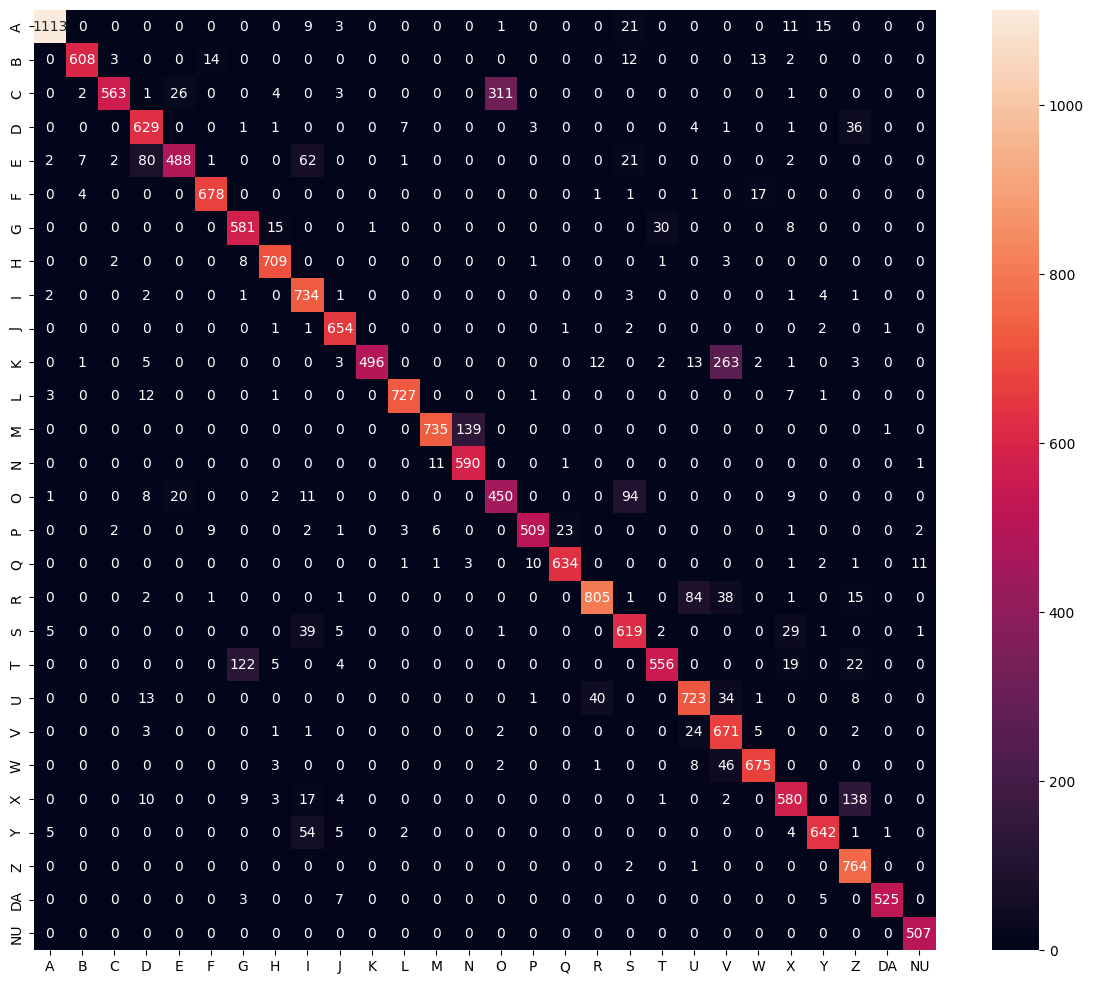

Classification Report
              precision    recall  f1-score   support

           A       0.98      0.95      0.97      1173
           B       0.98      0.93      0.95       652
           C       0.98      0.62      0.76       911
           D       0.82      0.92      0.87       683
           E       0.91      0.73      0.81       666
           F       0.96      0.97      0.97       702
           G       0.80      0.91      0.85       635
           H       0.95      0.98      0.97       724
           I       0.79      0.98      0.87       749
           J       0.95      0.99      0.97       662
           K       1.00      0.62      0.76       801
           L       0.98      0.97      0.97       752
           M       0.98      0.84      0.90       875
           N       0.81      0.98      0.88       603
           O       0.59      0.76      0.66       595
           P       0.97      0.91      0.94       558
           Q       0.96      0.95      0.96       664
     

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    label_ids = sorted(list(set(y_true)))
    label_names = [labels[i] for i in label_ids]
    cmx_data = confusion_matrix(y_true, y_pred, labels=label_ids)
    
    df_cmx = pd.DataFrame(cmx_data, index=label_names, columns=label_names)
 
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.tight_layout()
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(label_ids), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred, labels=label_ids, target_names=label_names))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

e:\licenta\DeafEar\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmpo_v9xea0\assets


INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmpo_v9xea0\assets


11032

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 15.6 ms
Wall time: 3.03 ms


In [22]:
tflite_results = globals().get('tflite_results')
if tflite_results is None:
    print('tflite_results is not available')
else:
    print(np.squeeze(tflite_results))
    print(np.argmax(np.squeeze(tflite_results)))


[7.95716107e-01 8.28509095e-10 5.51809265e-10 5.86988556e-08
 4.56105590e-06 5.46999445e-06 2.62993876e-06 2.91680607e-07
 9.43108182e-03 2.26964767e-04 3.44190485e-05 4.46800004e-05
 4.15761349e-07 3.26065355e-11 4.63652141e-05 2.30689293e-05
 4.17295851e-05 2.37268760e-09 9.06458416e-04 1.37931875e-05
 1.82282002e-11 1.68753886e-10 1.52107498e-15 1.74105517e-05
 1.93449110e-01 2.22917218e-09 3.53122778e-05 2.38542608e-08]
0
